In [218]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,f1_score

In [10]:
df=pd.read_csv(r"C:\Users\Pranjali kiran Bokad\Downloads\Breast_Cancer.csv")

In [11]:
df.head(5)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


# Data Visualization and EDA

In [12]:
df.shape

(4024, 16)

In [13]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [14]:
df.duplicated().sum().sum()

np.int64(1)

In [15]:
df.columns=df.columns.str.strip()


In [16]:
df=df.drop_duplicates(keep="first")

In [17]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,53.969923,30.477007,14.358439,4.158837,71.301765
std,8.963118,21.121253,8.100241,5.109724,22.923009
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4023 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4023 non-null   int64 
 1   Race                    4023 non-null   object
 2   Marital Status          4023 non-null   object
 3   T Stage                 4023 non-null   object
 4   N Stage                 4023 non-null   object
 5   6th Stage               4023 non-null   object
 6   differentiate           4023 non-null   object
 7   Grade                   4023 non-null   object
 8   A Stage                 4023 non-null   object
 9   Tumor Size              4023 non-null   int64 
 10  Estrogen Status         4023 non-null   object
 11  Progesterone Status     4023 non-null   object
 12  Regional Node Examined  4023 non-null   int64 
 13  Reginol Node Positive   4023 non-null   int64 
 14  Survival Months         4023 non-null   int64 
 15  Status   

In [19]:
df["Tumor Size"]=df["Tumor Size"].clip(upper=100)
df["Regional Node Examined"]=df["Regional Node Examined"].clip(upper=40)

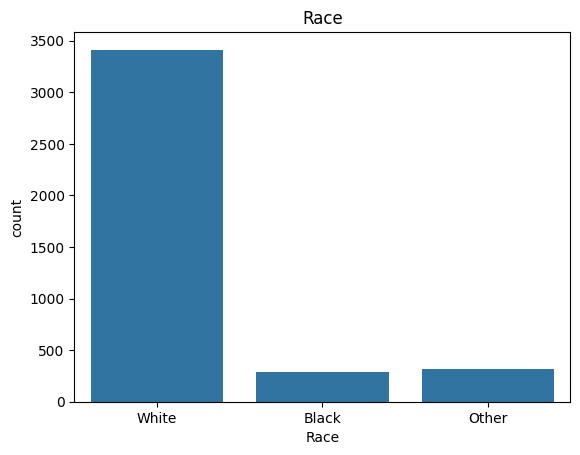

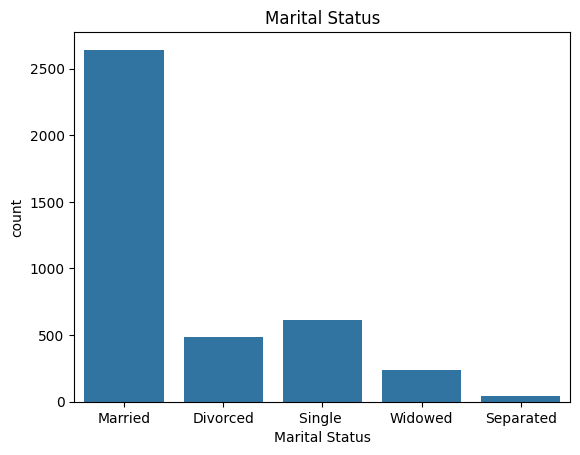

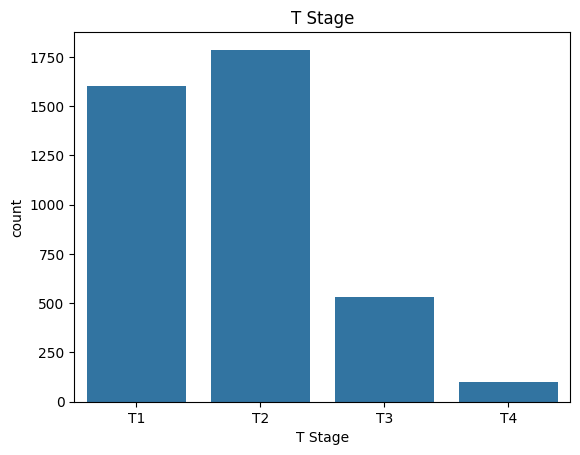

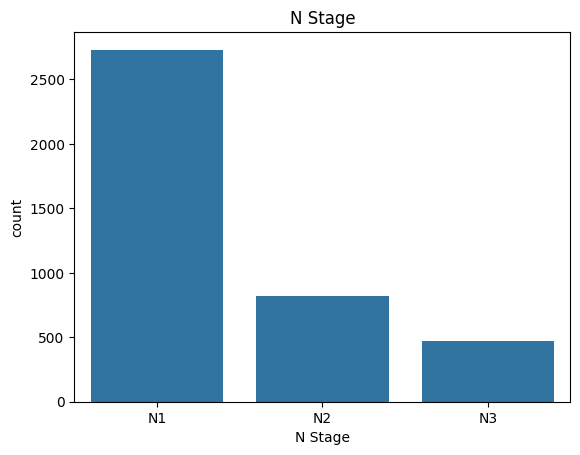

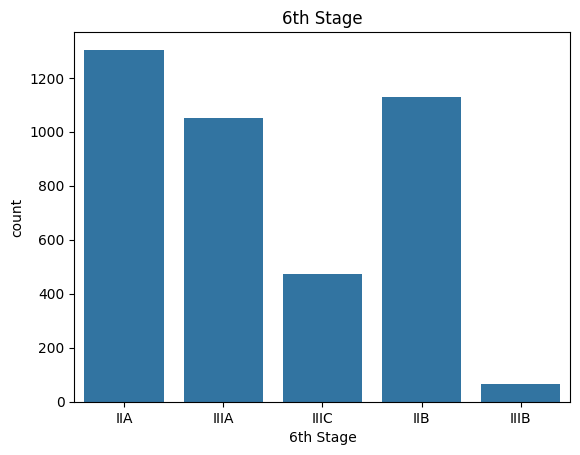

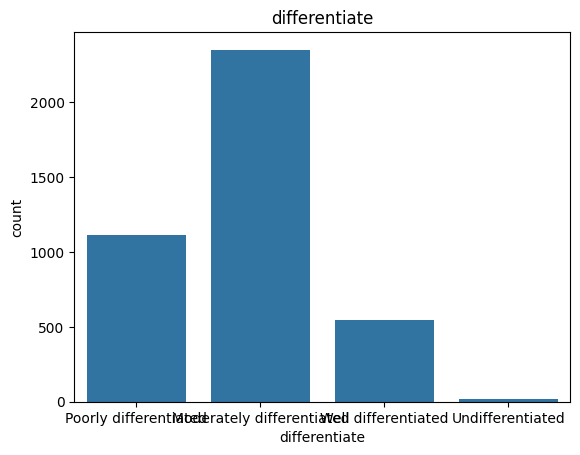

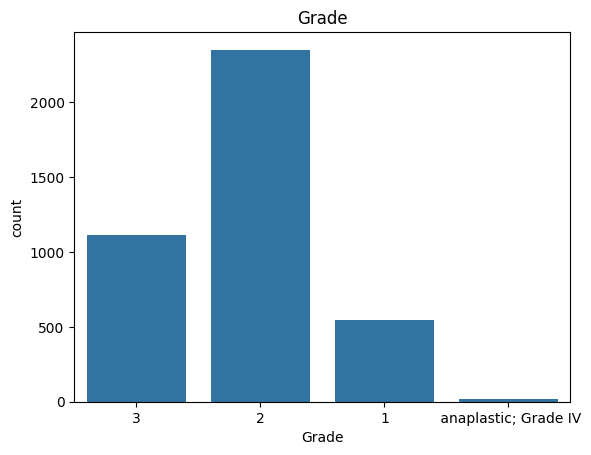

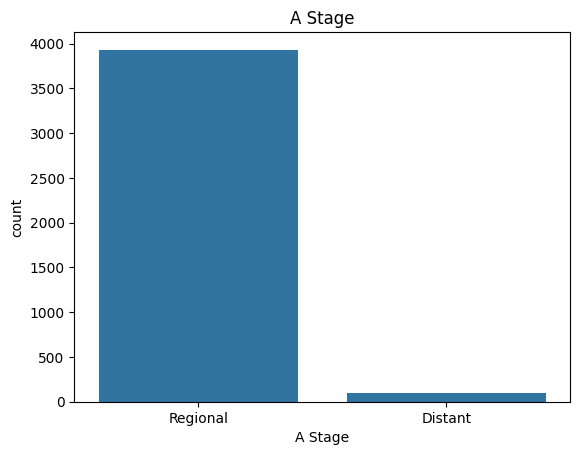

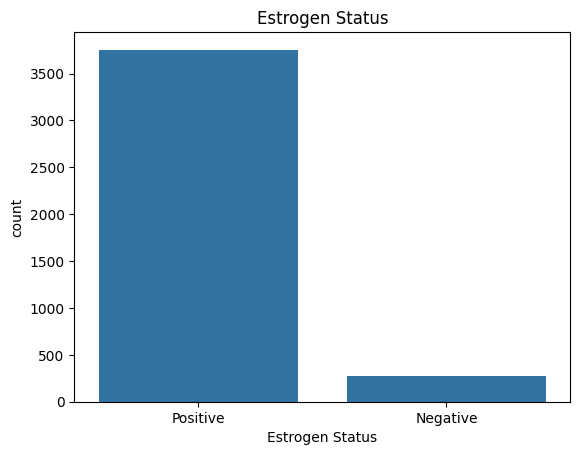

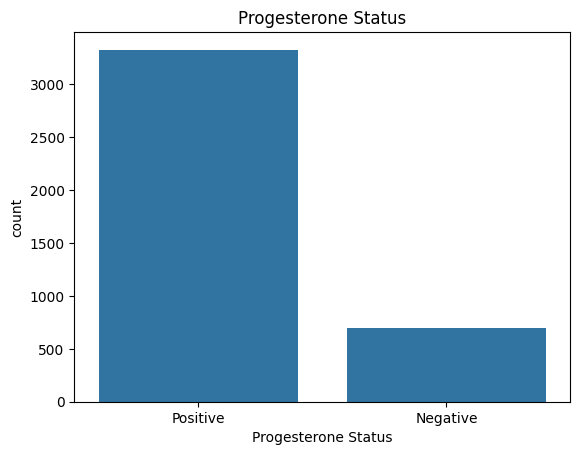

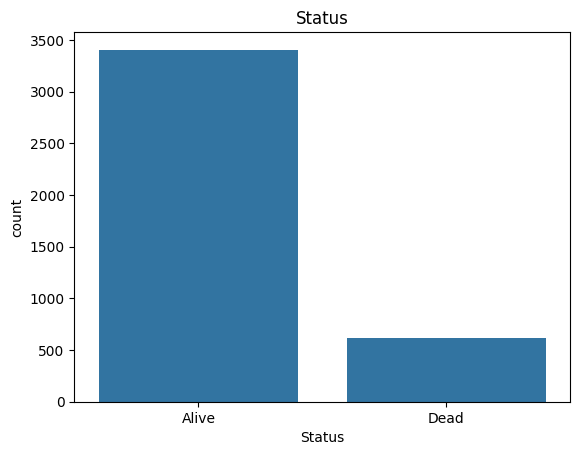

In [20]:
cols=df.select_dtypes(include=["object"]).columns

for i in cols:
    sns.countplot(x=df[i])
    plt.title(i)
    plt.show()

Text(0.5, 1.0, 'Survival by T Stage - Higher T=More Deaths?')

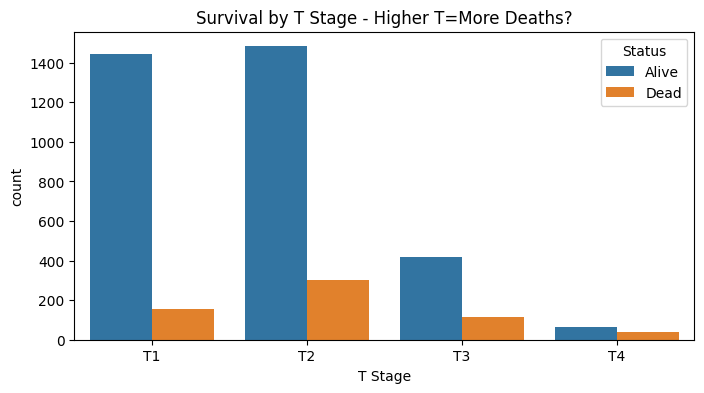

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x="T Stage",hue="Status",data=df)
plt.title("Survival by T Stage - Higher T=More Deaths?")

<Axes: xlabel='N Stage', ylabel='count'>

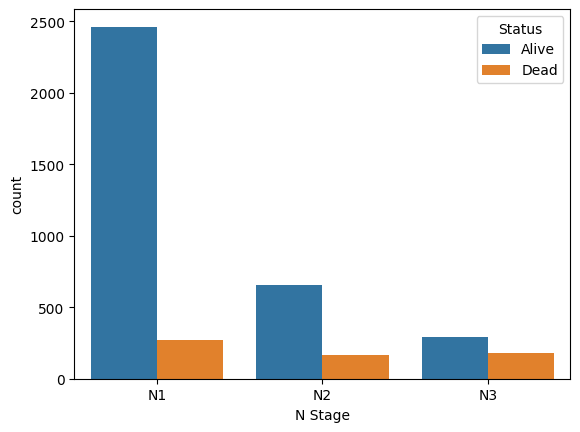

In [22]:
sns.countplot(x="N Stage",hue="Status",data=df)

<Axes: xlabel='6th Stage', ylabel='count'>

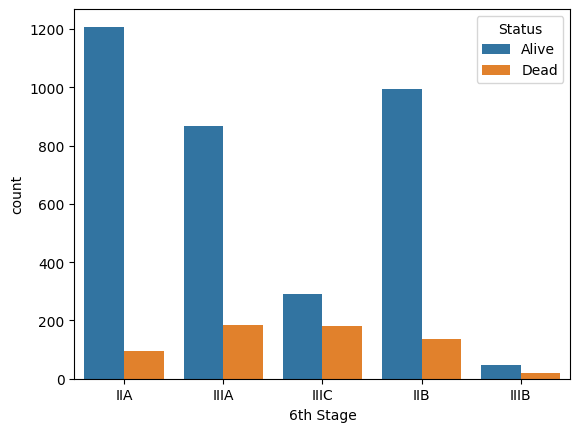

In [23]:
sns.countplot(x="6th Stage",hue="Status",data=df)

<Axes: xlabel='Grade', ylabel='count'>

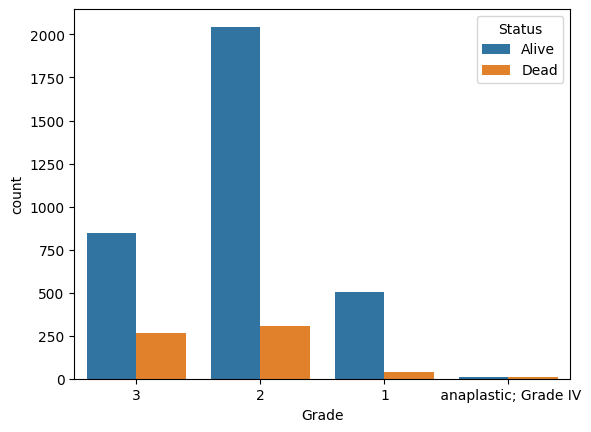

In [24]:
sns.countplot(x="Grade",hue="Status",data=df)

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_6460\1372470136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


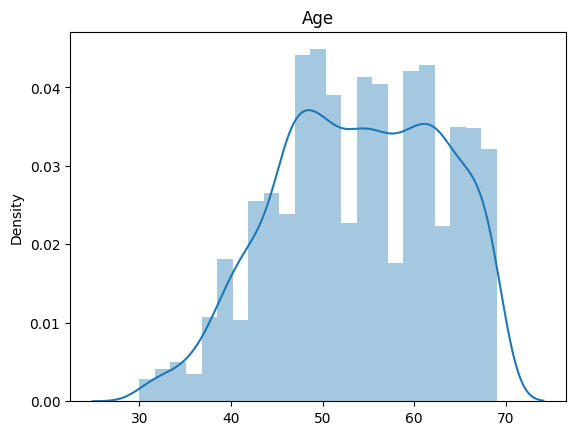

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_6460\1372470136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


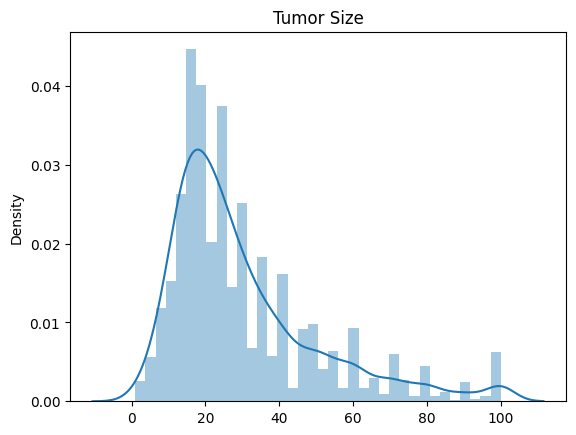

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_6460\1372470136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


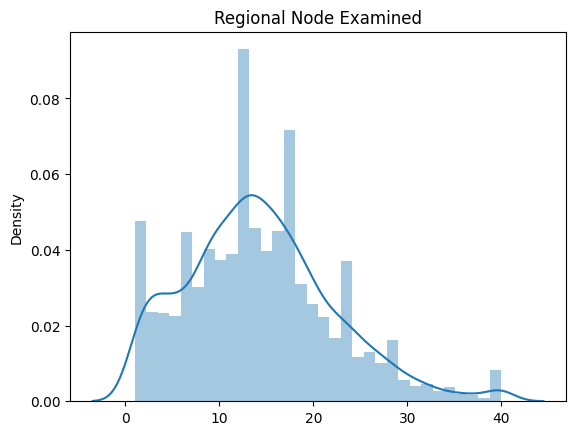

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_6460\1372470136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


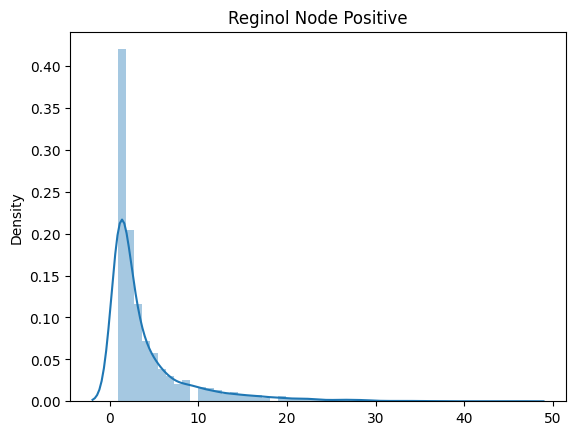

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_6460\1372470136.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


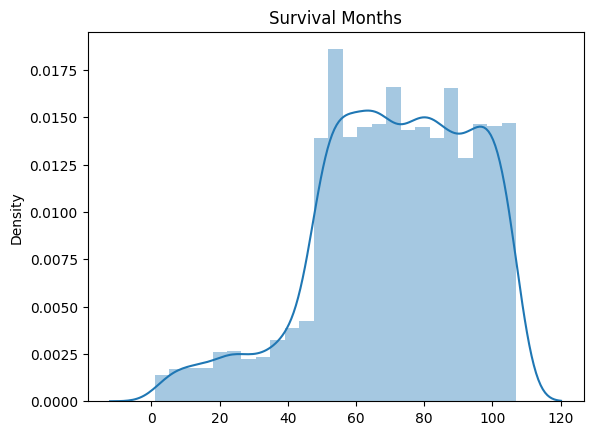

In [25]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
   sns.distplot(x=df[i])
   plt.title(i)
   plt.show()

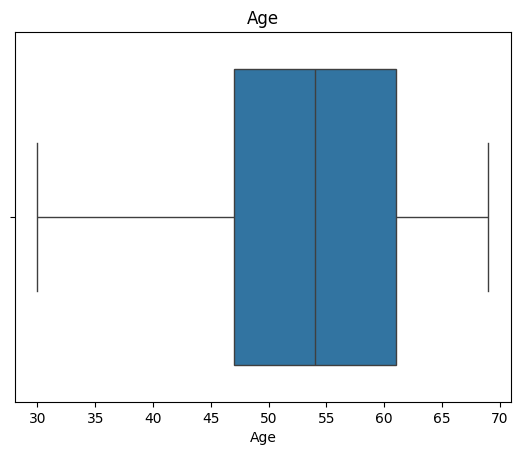

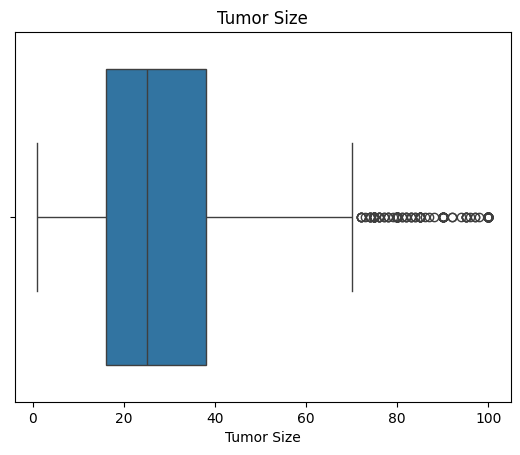

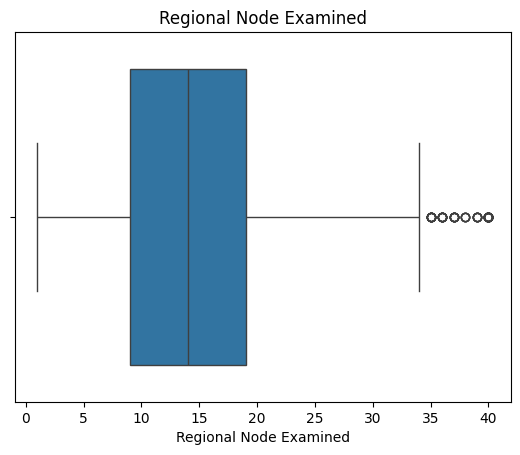

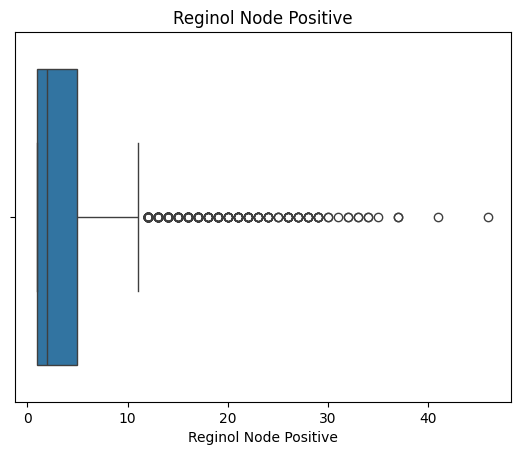

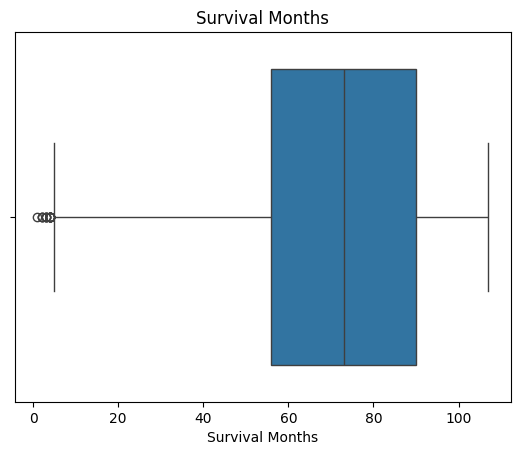

In [26]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
   sns.boxplot(x=df[i])
   plt.title(i)
   plt.show()

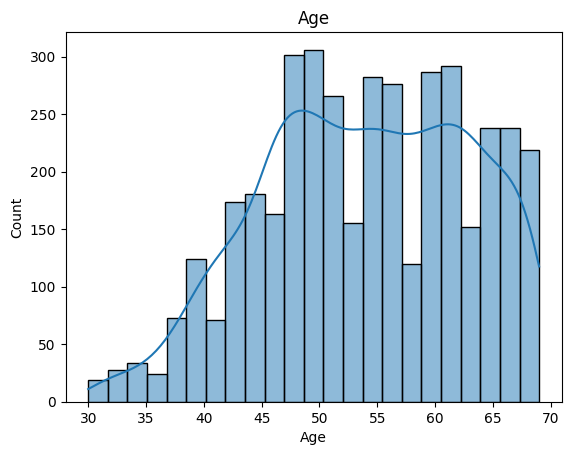

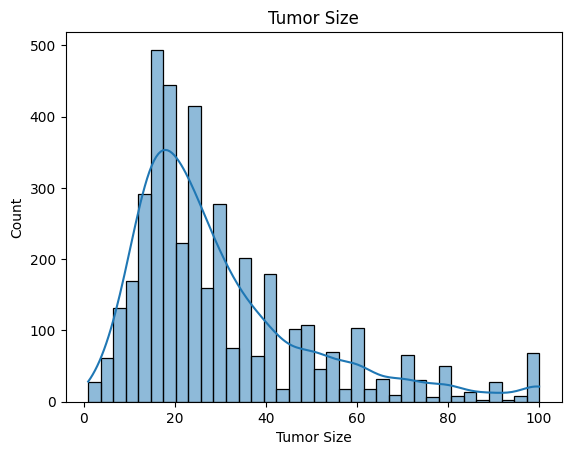

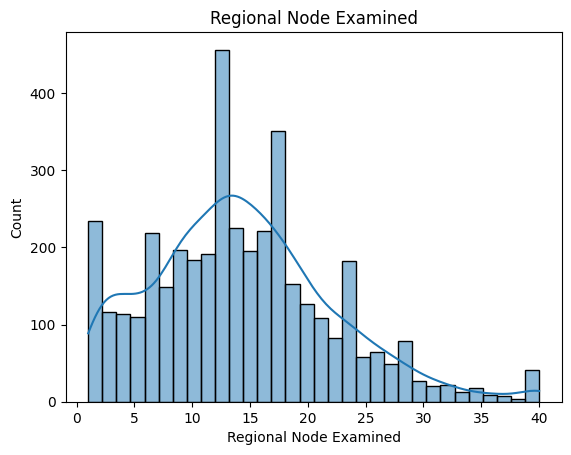

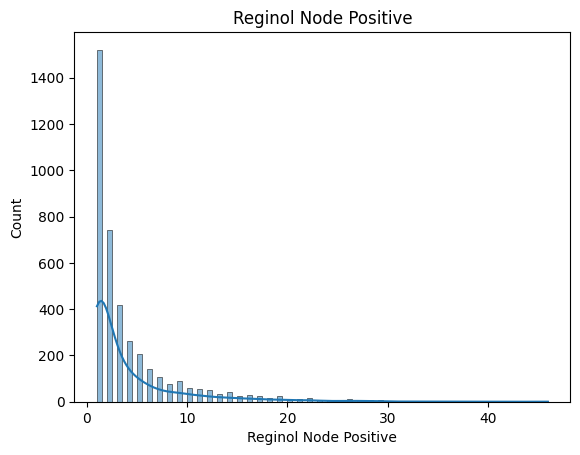

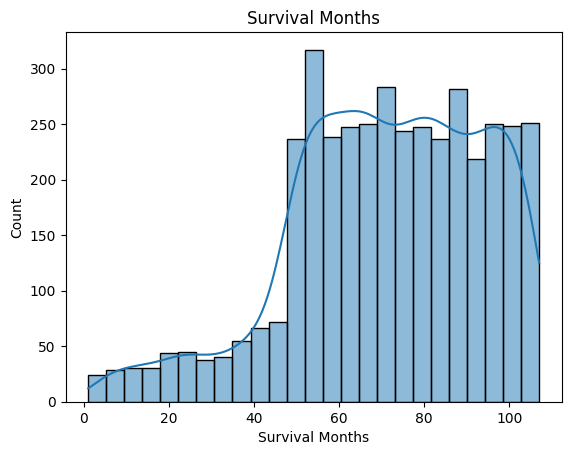

In [27]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
   sns.histplot(x=df[i],kde=True)
   plt.title(i)
   plt.show()

Text(0.5, 1.0, 'Tumor Size:Dead patients have larger tumors?')

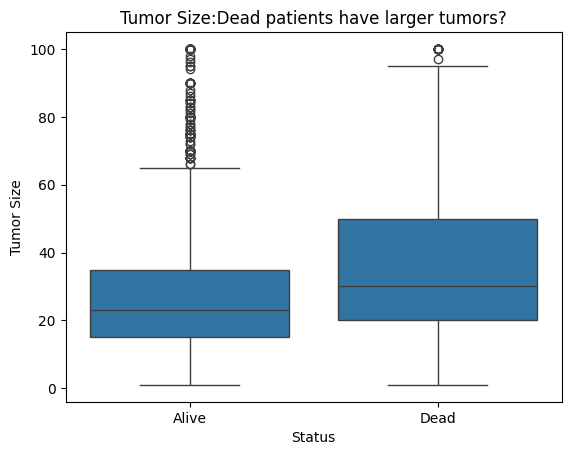

In [28]:
sns.boxplot(x="Status",y="Tumor Size",data=df)
plt.title("Tumor Size:Dead patients have larger tumors?")

<Axes: xlabel='Status', ylabel='Tumor Size'>

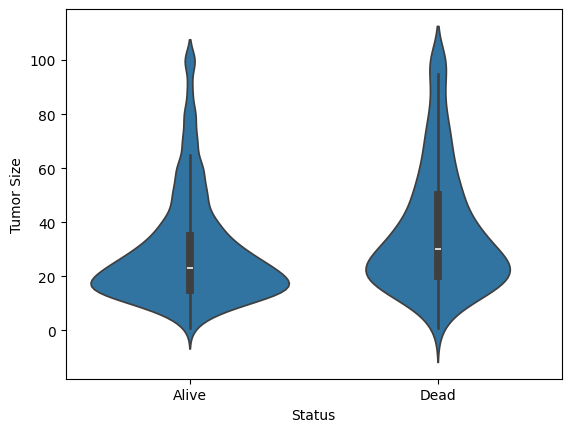

In [29]:
sns.violinplot(x="Status",y="Tumor Size",data=df)


<Axes: xlabel='Status', ylabel='Regional Node Examined'>

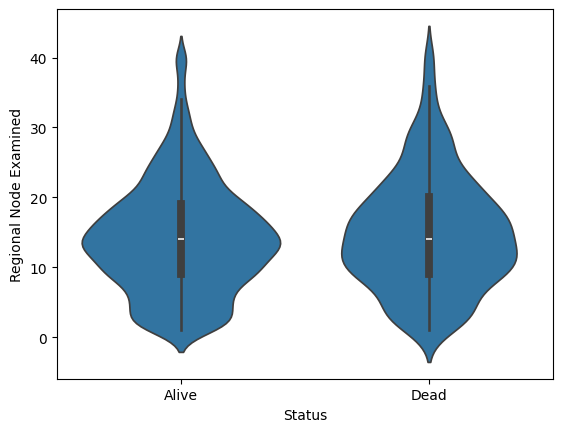

In [30]:
sns.violinplot(x="Status",y="Regional Node Examined",data=df)

<Axes: xlabel='Progesterone Status', ylabel='count'>

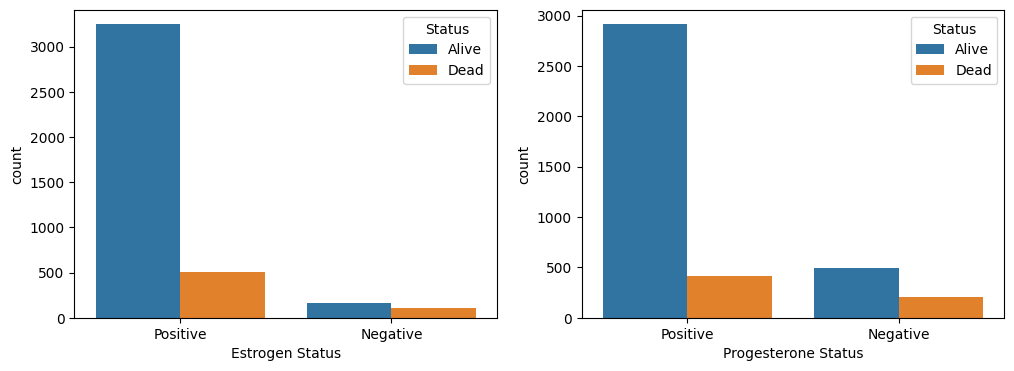

In [31]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.countplot(x="Estrogen Status",hue="Status",data=df,ax=ax[0])
sns.countplot(x="Progesterone Status",hue="Status",data=df,ax=ax[1])

Text(0.5, 1.0, 'Survival Months - Do Dead patients have lower months?')

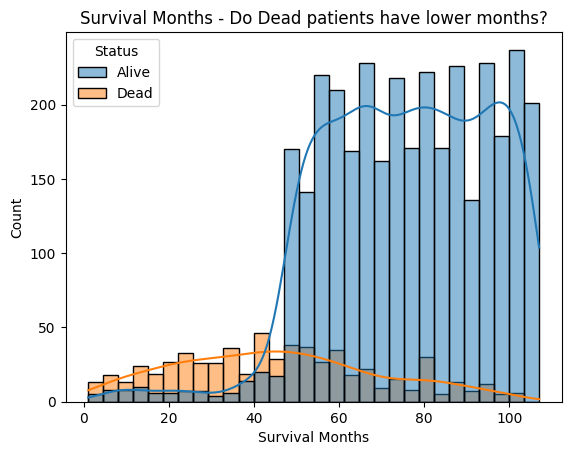

In [32]:
sns.histplot(data=df,x="Survival Months",hue="Status",kde=True,bins=30)
plt.title("Survival Months - Do Dead patients have lower months?")

<Axes: xlabel='Age Group', ylabel='count'>

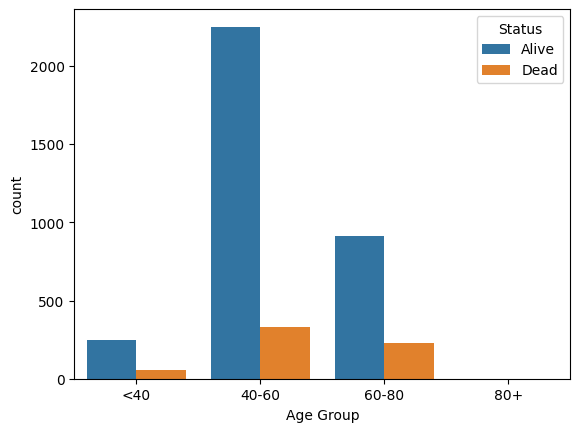

In [33]:
df["Age Group"]=pd.cut(df["Age"],bins=[0,40,60,80,100],labels=["<40","40-60","60-80","80+"])
sns.countplot(x="Age Group",hue="Status",data=df)

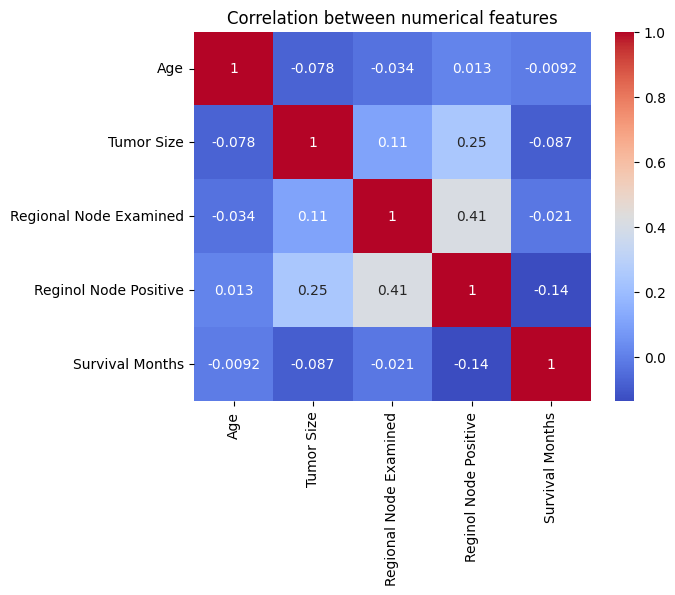

In [34]:
num_cols=["Age","Tumor Size","Regional Node Examined","Reginol Node Positive","Survival Months"]
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation between numerical features")
plt.show()

# Feature Engineering

In [199]:
df["Tumor Size"]=df["Tumor Size"].clip(upper=100)
df["Regional Node Examined"]=df["Regional Node Examined"].clip(upper=40)
df["Is_High_Risk"]=((df["Tumor Size"]>50)&(df["Reginol Node Positive"]>3)).astype(int)
df["Node_Ratio"]=df["Reginol Node Positive"]/(df["Regional Node Examined"]+1)
df["Node_Ratio"]=df["Node_Ratio"].clip(0,1)

df["Is_Triple_Neg"]=((df["Estrogen Status"]=="Negative")&(df["Progesterone Status"]=="Negative")).astype(int)
df["High_Tumor"]=(df["Tumor Size"]>50).astype(int)

df["Is_High_Risk"]=((df["Tumor Size"]>50)&(df["Reginol Node Positive"]>3)).astype(int)

# Train Test Split

In [200]:
x=df.drop(["Status","Survival Months","Age Group"],axis=1)
y=df["Status"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [201]:
cat_cols=['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']
num_cols=['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']

In [202]:
print("Categorical Columns",cat_cols)
print("Numeric Columns",num_cols)

Categorical Columns ['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']
Numeric Columns ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']


In [203]:
le=LabelEncoder()
ord_map={"Alive":0,"Dead":1}
y_train=y_train.map(ord_map)
y_test=y_test.map(ord_map)

In [204]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3218 entries, 479 to 3889
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3218 non-null   int64  
 1   Race                    3218 non-null   object 
 2   Marital Status          3218 non-null   object 
 3   T Stage                 3218 non-null   object 
 4   N Stage                 3218 non-null   object 
 5   6th Stage               3218 non-null   object 
 6   differentiate           3218 non-null   object 
 7   Grade                   3218 non-null   object 
 8   A Stage                 3218 non-null   object 
 9   Tumor Size              3218 non-null   int64  
 10  Estrogen Status         3218 non-null   object 
 11  Progesterone Status     3218 non-null   object 
 12  Regional Node Examined  3218 non-null   int64  
 13  Reginol Node Positive   3218 non-null   int64  
 14  Is_High_Risk            3218 non-null   int

# Pipeline

In [205]:
onehot_cols=['Race','Marital Status','differentiate','Estrogen Status','Progesterone Status']
ord_cols=['Grade','A Stage','6th Stage','T Stage','N Stage']

grade_ord=['Grade 1','Grade 2','Grade 3','Grade 4']
A_stage_ord=['Regional','Distant']
stage6_ord=['I','IIA','IIB','IIIA','IIIB','IIIC']
t_stage_ord=['T1','T2','T3','T4']
n_stage_ord=['N1','N2','N3']

In [206]:
ct=ColumnTransformer(
    transformers=[
        ("onehot_cols",OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False),onehot_cols),
        ("ord_cols",OrdinalEncoder(categories=[grade_ord,A_stage_ord,stage6_ord,t_stage_ord,n_stage_ord],handle_unknown='use_encoded_value',unknown_value=-1),ord_cols),
        ("std_col",StandardScaler(),num_cols)
    ],remainder='passthrough'
)

In [207]:
neg,pos=(y_train==0).sum(),(y_train==1).sum()
scale=neg/pos
print(scale)

5.52738336713996


In [236]:
xgb=XGBClassifier(scale_pos_weight=scale,max_depth=3,learning_rate=0.08,subsample=0.7,colsample_bytree=0.7,reg_alpha=1.0,reg_lambda=2.0,n_estimators=150,min_child_weight=4,random_state=42)
rf=RandomForestClassifier(n_estimators=0,max_depth=6,random_state=42,class_weight='balanced')

merged_model=VotingClassifier(
    estimators=[('xgb',xgb),('rf',rf)],
    voting='soft'
)

In [237]:
pipeline=Pipeline([
    ("ct",ct),
    ("vt",merged_model)
])

In [238]:
pipeline.fit(x_train,y_train)

,steps,"[('ct', ...), ('vt', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_cols', ...), ('ord_cols', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [239]:
y_train_pred=pipeline.predict(x_train)
print("Accuracy:",accuracy_score(y_train,y_train_pred))

Accuracy: 0.7846488502175264


In [240]:
y_test_pred=pipeline.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_test_pred))

Accuracy: 0.7428571428571429


In [241]:
cross_val_score(pipeline,x_train,y_train,cv=5,scoring="accuracy").mean()

np.float64(0.7501695275446036)

# Confusion Matrix

In [242]:
proba = pipeline.predict_proba(x_test)[:,1]

for r in [0.12,0.15,0.18,0.20,0.22,0.25,0.30,0.33,0.37,0.40,0.50]:
    y_pred=(proba>r).astype(int)
    f1=f1_score(y_test,y_pred)
    recall_dead=(y_pred[y_test==1]==1).mean()
    print(f"Thresh {r} -> F1: {f1:.3f} | Recall Dead: {recall_dead:.2%}")

Thresh 0.12 -> F1: 0.270 | Recall Dead: 100.00%
Thresh 0.15 -> F1: 0.275 | Recall Dead: 99.19%
Thresh 0.18 -> F1: 0.282 | Recall Dead: 98.37%
Thresh 0.2 -> F1: 0.283 | Recall Dead: 95.12%
Thresh 0.22 -> F1: 0.289 | Recall Dead: 92.68%
Thresh 0.25 -> F1: 0.306 | Recall Dead: 91.06%
Thresh 0.3 -> F1: 0.347 | Recall Dead: 88.62%
Thresh 0.33 -> F1: 0.348 | Recall Dead: 82.93%
Thresh 0.37 -> F1: 0.367 | Recall Dead: 79.67%
Thresh 0.4 -> F1: 0.370 | Recall Dead: 73.17%
Thresh 0.5 -> F1: 0.400 | Recall Dead: 56.10%


In [243]:
thresh=0.50
pred_test=(pipeline.predict_proba(x_test)[:,1]>=thresh).astype(int)
pred_train=(pipeline.predict_proba(x_train)[:,1]>=thresh).astype(int)

print("Train",accuracy_score(y_train,pred_train),f1_score(y_train,pred_train))
print("Test",accuracy_score(y_test,pred_test),f1_score(y_test,pred_test))


Train 0.7846488502175264 0.49673202614379086
Test 0.7428571428571429 0.4


In [227]:
cm=confusion_matrix(y_test,pred_test)
cm

array([[522, 160],
       [ 54,  69]])

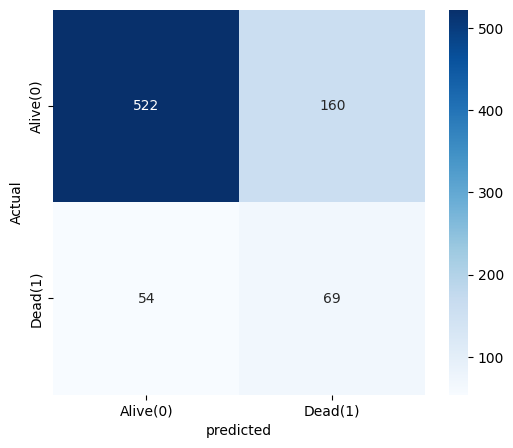

In [228]:
class_names=['Alive(0)','Dead(1)']

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
       xticklabels=class_names,
       yticklabels=class_names)
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [229]:
print(classification_report(y_test,pred_test))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83       682
           1       0.30      0.56      0.39       123

    accuracy                           0.73       805
   macro avg       0.60      0.66      0.61       805
weighted avg       0.81      0.73      0.76       805

